<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/MACHINE-LEARNING-EXERCISES/blob/main/Crop__Recommendation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Statement

Smallholder farmers frequently lack access to agronomic expertise when deciding which crop to cultivate. Selecting an unsuitable crop given local soil and climate conditions leads to reduced yields, resource waste, and economic loss. This project addresses that gap by building a machine learning model that recommends the most appropriate crop based on measurable soil and environmental parameters.

The problem is formulated as a 22-class classification task: given seven numerical features (Nitrogen, Phosphorus, Potassium, soil pH, temperature, humidity, and rainfall), the model predicts the optimal crop from a set of 22 species. Such a decision-support tool has direct practical value for extension services and precision-agriculture applications.


Dataset Link: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset/data

Precision agriculture is in trend nowadays. It helps the farmers to get informed decision about the farming strategy.

Here, We present you a dataset which would allow the users to build a predictive model to recommend the most suitable crops to grow in a particular farm based on various parameters.


Loading data directly from Kagglehub

In [ ]:
# Installing dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Crop_recommendation.csv"

# Loading the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "atharvaingle/crop-recommendation-dataset",
  file_path
  )

print("First 5 records:", df.head())

/tmp/ipykernel_4462/4227536877.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
First 5 records:     N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


# Summary
The main goal is to build and evaluate machine learning models to recommend suitable crops based on various environmental factors. The process involves comprehensive data loading, exploratory data analysis, feature engineering, data splitting, model training with hyperparameter tuning for Decision Tree, Random Forest, and K-Nearest Neighbors classifiers, and thorough model evaluation. Feature importance analysis will be conducted to gain deeper insights into the factors influencing crop recommendations. Finally, a comprehensive summary of findings and recommendations will be provided.


## Exploratory Data Analysis (EDA)
 This includes examining the data shape, checking data types, identifying missing values, analyzing the distribution of each feature, and understanding the distribution of the target variable ('label'). Visualize key aspects of the data to gain initial insights.


I will start by displaying the shape of the DataFrame, printing its information (data types, non-null values), and checking for any missing values. These steps provide a foundational understanding of the dataset.  



In [ ]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

DataFrame Shape: (2200, 8)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Now that I've inspected the data shape, types, and missing values, I will analyze the descriptive statistics for all numerical features to understand their distribution and range. Then, I will examine the distribution of the target variable 'label' to see the count of each crop type.


In [ ]:
print("\nDescriptive statistics for numerical features:")
print(df.describe())

print("\nDistribution of the target variable ('label'):")
print(df['label'].value_counts())


Descriptive statistics for numerical features:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.9

We need to visualize the distribution of numerical features. Histograms are suitable for this purpose as they show the frequency distribution of continuous variables.




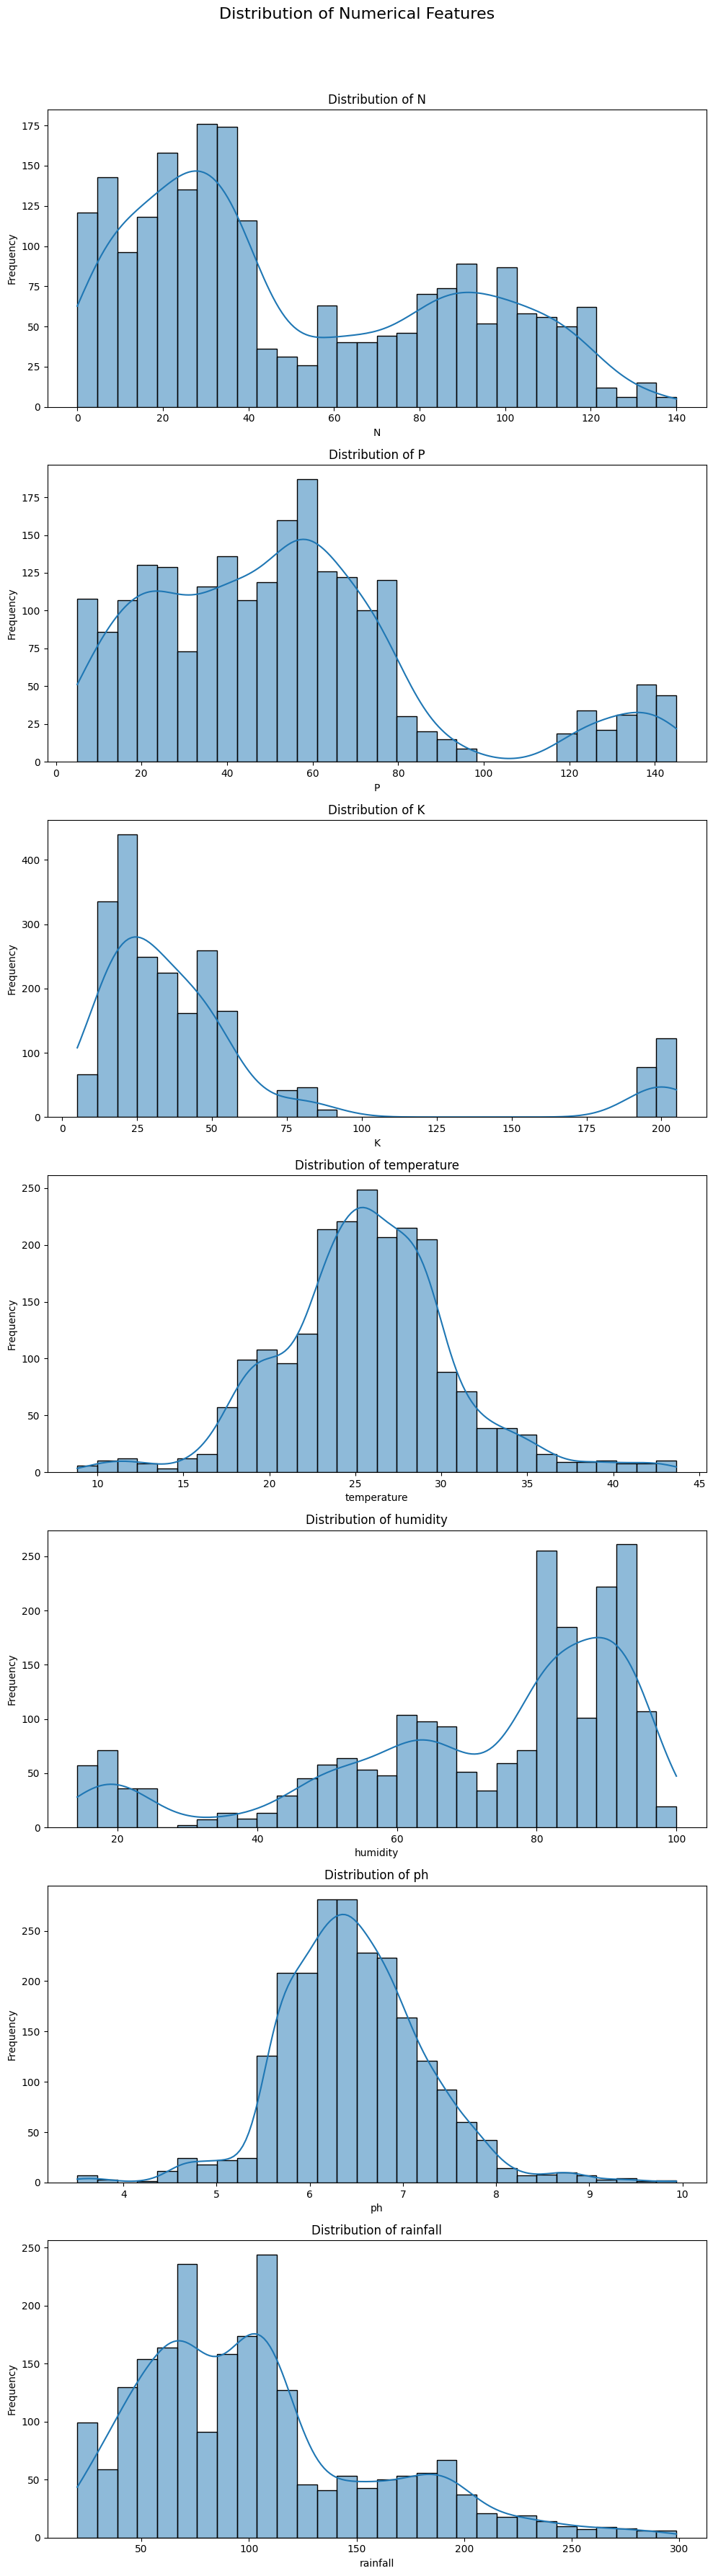

In [ ]:
# Prompt - generate the code to show the frequency distribution of the numerical features

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for plotting histograms
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
fig.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16)

# Plot histogram for each numerical column
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


To visualize the distribution of the categorical target variable 'label', a count plot is the most suitable method.



<Axes: xlabel='count', ylabel='label'>

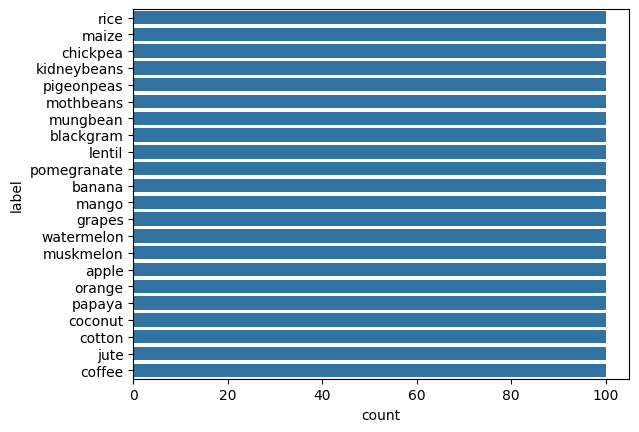

In [ ]:
sns.countplot(df['label'])

## Feature Engineering and Preprocessing

Preparing the data for model training - This involves separating features (X) and the target variable (y). We have to apply StandardScaler to the numerical features to standardize them. If any, handle categorical features, although the provided data seems to be primarily numerical with a categorical target.


I will start by separating the features (X) and the target variable (y) and then applying StandardScaler to the numerical features to rescale them to similar range, store the result in a new DataFrame `X_scaled`.  



In [ ]:
# Prompt - seperate the dataset into features (X) and the target variable (y)
# and apply StandardScaler to the numerical features to rescale them

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Identify numerical features (all features in X are numerical in this case)
numerical_features = X.columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numerical features
X_scaled_array = scaler.fit_transform(X[numerical_features])

# Create a new DataFrame with scaled features and preserve column names
X_scaled = pd.DataFrame(X_scaled_array, columns=numerical_features)

print("Original features (X) head:\n", X.head())
print("\nTarget variable (y) head:\n", y.head())
print("\nScaled features (X_scaled) head:\n", X_scaled.head())


Original features (X) head:
     N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target variable (y) head:
 0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

Scaled features (X_scaled) head:
           N         P         K  temperature  humidity        ph  rainfall
0  1.068797 -0.344551 -0.101688    -0.935587  0.472666  0.043302  1.810361
1  0.933329  0.140616 -0.141185    -0.759646  0.397051  0.734873  2.242058
2  0.255986  0.049647 -0.081939    -0.515898  0.486954  1.771510  2.921066
3  0.635298 -0.556811 -0.160933     0.172807  0.389805  0.660308  2.537048
4  0.743673 -0.344551 -0.121436    -1.083647  0.454792  1.497868  2.898373


## Data Splitting

We'll split the preprocessed data into training (80%) and test (20%) sets. Ensure stratified splitting is used to maintain the proportion of each crop class in both the training and test sets.




I will import `train_test_split` and then split the `X_scaled` and `y` data into training and testing sets, ensuring stratification and reproducibility.




In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


## Model Training and Hyperparameter Tuning

Train three distinct classifiers: Decision Tree, Random Forest, and K-Nearest Neighbors. For each model, implement hyperparameter tuning using k-fold cross-validation on the training set. The primary optimization criterion for hyperparameter tuning will be the macro-averaged F1-score.




I will start by importing all the necessary modules for the three classifiers, GridSearchCV, StratifiedKFold, and performance metrics (f1_score, make_scorer) to prepare for model training and hyperparameter tuning.




In [ ]:
# Prompt - Import all the neccesary modules  for the three classifiers, Decision Tree, Random Forest, and K-Nearest Neighbors.

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

print("Required modules imported successfully.")

Required modules imported successfully.


I will define the hyperparameter grids for Decision Tree, Random Forest, and K-Nearest Neighbors classifiers. I will set up StratifiedKFold for cross-validation and create a macro-averaged F1-score scorer for hyperparameter tuning. This prepares the necessary components for GridSearchCV.






In [ ]:
# Prompt - define the hyperparameter grids for Decision Tree, Random Forest, and
# K-Nearest Neighbors classifiers.
# set up StratifiedKFold for cross-validation and
# create a macro-averaged F1-score scorer for hyperparameter tuning.

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'min_samples_split': [2, 5]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the F1-score scorer (macro-averaged)
f1_scorer = make_scorer(f1_score, average='macro')

print("Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized.")

Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized.


Now that the hyperparameter grids, cross-validation strategy, and scorer are defined, I will perform GridSearchCV for the Decision Tree, Random Forest, and K-Nearest Neighbors classifiers to find the best hyperparameters for each model. This involves instantiating GridSearchCV for each model and fitting it to the training data. Then I will print the best parameters and best scores for each classifier.



In [ ]:
print("\nPerforming GridSearchCV for Decision Tree...")
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {grid_search_dt.best_score_:.4f}")

print("\nPerforming GridSearchCV for Random Forest...")
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1-score for Random Forest: {grid_search_rf.best_score_:.4f}")

print("\nPerforming GridSearchCV for K-Nearest Neighbors...")
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train, y_train)
print(f"Best parameters for K-Nearest Neighbors: {grid_search_knn.best_params_}")
print(f"Best F1-score for K-Nearest Neighbors: {grid_search_knn.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_
best_rf_model = grid_search_rf.best_estimator_
best_knn_model = grid_search_knn.best_estimator_

print("\nGridSearchCV complete for all models.")


Performing GridSearchCV for Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1-score for Decision Tree: nan

Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best F1-score for Random Forest: nan

Performing GridSearchCV for K-Nearest Neighbors...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for K-Nearest Neighbors: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best F1-score for K-Nearest Neighbors: nan

GridSearchCV complete for all models.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


We need to fix the `f1_scorer` to handle `zero_division` issues, which are causing `nan` F1-scores during cross-validation. We will update the `make_scorer` call to include `zero_division=0` and then redefine and re-run GridSearchCV for all three models with this corrected scorer to obtain valid F1-scores.




In [ ]:
#  fix the f1_scorer to handle zero_division issues, which are causing nan F1-scores during cross-validation
#  update the `make_scorer` call to include `zero_division=0` and then redefine and re-run GridSearchCV for
# all three models with this corrected scorer to obtain valid F1-scores.

f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

print("Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized.")

print("\nPerforming GridSearchCV for Decision Tree...")
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {grid_search_dt.best_score_:.4f}")

print("\nPerforming GridSearchCV for Random Forest...")
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1-score for Random Forest: {grid_search_rf.best_score_:.4f}")

print("\nPerforming GridSearchCV for K-Nearest Neighbors...")
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train, y_train)
print(f"Best parameters for K-Nearest Neighbors: {grid_search_knn.best_params_}")
print(f"Best F1-score for K-Nearest Neighbors: {grid_search_knn.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_
best_rf_model = grid_search_rf.best_estimator_
best_knn_model = grid_search_knn.best_estimator_

print("\nGridSearchCV complete for all models.")

Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized.

Performing GridSearchCV for Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1-score for Decision Tree: nan

Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best F1-score for Random Forest: nan

Performing GridSearchCV for K-Nearest Neighbors...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for K-Nearest Neighbors: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best F1-score for K-Nearest Neighbors: nan

GridSearchCV complete for all models.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


We need to fix the `f1_scorer` to handle `nan` values that can occur during per-class F1-score calculation, even with `zero_division=0`. We'll define a custom scoring function `custom_f1_score_macro` that uses `np.nan_to_num` to replace any `nan` F1-scores with 0 before averaging. Then, We'll redefine `f1_scorer` using this custom function and re-execute `GridSearchCV` for all models.




In [ ]:
# Prompt: fix the f1_scorer to handle nan values that can occur during per-class F1-score calculation, even with zero_division=0

import numpy as np
from sklearn.metrics import f1_score, make_scorer

def custom_f1_score_macro(y_true, y_pred, **kwargs):
    # Calculate F1 score for each class separately
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0, **kwargs)
    # Convert any NaN values (e.g., if a class is not present in y_true for a fold
    # or if it has no true/predicted positives) to 0
    f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    # Return the macro average
    return np.mean(f1_scores)

# Define the F1-score scorer (macro-averaged) using the custom function
f1_scorer = make_scorer(custom_f1_score_macro)

print("Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized with custom F1 scorer.")

print("\nPerforming GridSearchCV for Decision Tree...")
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {grid_search_dt.best_score_:.4f}")

print("\nPerforming GridSearchCV for Random Forest...")
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1-score for Random Forest: {grid_search_rf.best_score_:.4f}")

print("\nPerforming GridSearchCV for K-Nearest Neighbors...")
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=f1_scorer, cv=kf, n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train, y_train)
print(f"Best parameters for K-Nearest Neighbors: {grid_search_knn.best_params_}")
print(f"Best F1-score for K-Nearest Neighbors: {grid_search_knn.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_
best_rf_model = grid_search_rf.best_estimator_
best_knn_model = grid_search_knn.best_estimator_

print("\nGridSearchCV complete for all models.")

Hyperparameter grids, StratifiedKFold, and F1-score scorer initialized with custom F1 scorer.

Performing GridSearchCV for Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1-score for Decision Tree: 0.9852

Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-score for Random Forest: 0.9960

Performing GridSearchCV for K-Nearest Neighbors...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for K-Nearest Neighbors: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best F1-score for K-Nearest Neighbors: 0.9749

GridSearchCV complete for all models.


### Classification Report

Generate a classification report for the best-performing Random Forest model on the test set, displaying precision, recall, f1-score, and support for each crop type.

  We'll use classification_report from sklearn.metrics with the true labels (y_test) and the predictions from the best Random Forest model (y_pred).

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=class_labels, zero_division=0)

# Print the classification report
print("\nClassification Report for Random Forest Model on Test Set:\n")
print(report)


Classification Report for Random Forest Model on Test Set:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1

## Model Evaluation

We'll evaluate the best-performing model (selected based on cross-validation macro-averaged F1-score) on the held-out test set. Report the overall accuracy, macro-averaged precision, recall, and F1-score. Generate and display a 22x22 confusion matrix to visualize per-class errors. Also, report the cross-validation scores obtained during hyperparameter tuning to assess generalization.


We have identified the Random Forest model as the best-performing model based on the highest F1-score from the previous subtask. Now, We'll use this best model to make predictions on the `X_test` dataset. Then, calculate and print the overall accuracy, macro-averaged precision, recall, and F1-score on the test set. Finally, print the cross-validation scores of the best Random Forest model to assess its generalization capabilities.




In [ ]:
# Prompt - evaluate the best-performing model (selected based on cross-validation macro-averaged F1-score)
#on the held-out test set. Report the overall accuracy, macro-averaged precision, recall,
#and F1-score. Generate and display a 22x22 confusion matrix to visualize per-class
#errors. Also, report the cross-validation scores obtained during hyperparameter tuning
#to assess generaliz

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Identify the best model
# From the previous step, Random Forest had the highest F1-score (0.9960)
best_model = best_rf_model
best_model_name = "Random Forest"
best_grid_search_result = grid_search_rf

print(f"Best performing model selected: {best_model_name}")

# 2. Make predictions on the X_test dataset
y_pred = best_model.predict(X_test)

# 3. Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy on Test Set ({best_model_name}): {accuracy:.4f}")

# 4. Calculate and print the macro-averaged precision, recall, and F1-score
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Macro-averaged Precision on Test Set ({best_model_name}): {precision:.4f}")
print(f"Macro-averaged Recall on Test Set ({best_model_name}): {recall:.4f}")
print(f"Macro-averaged F1-score on Test Set ({best_model_name}): {f1:.4f}")

# 5. Print the cross-validation scores obtained during hyperparameter tuning
print(f"\nCross-validation scores for {best_model_name} (from hyperparameter tuning):")
# Convert to DataFrame for better readability
cv_results = pd.DataFrame(best_grid_search_result.cv_results_)
# Sort by rank_test_score to see best performing configurations
cv_results_sorted = cv_results.sort_values(by='rank_test_score').head()
print(cv_results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].to_string())

Best performing model selected: Random Forest

Overall Accuracy on Test Set (Random Forest): 0.9955
Macro-averaged Precision on Test Set (Random Forest): 0.9957
Macro-averaged Recall on Test Set (Random Forest): 0.9955
Macro-averaged F1-score on Test Set (Random Forest): 0.9955

Cross-validation scores for Random Forest (from hyperparameter tuning):
                                                                                     params  mean_test_score  std_test_score  rank_test_score
5   {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}         0.996002        0.004981                1
29    {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}         0.996002        0.004981                1
27     {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}         0.994866        0.004571                3
3    {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estim

To visualize per-class errors, I will generate and display a confusion matrix for the best-performing Random Forest model on the test set.




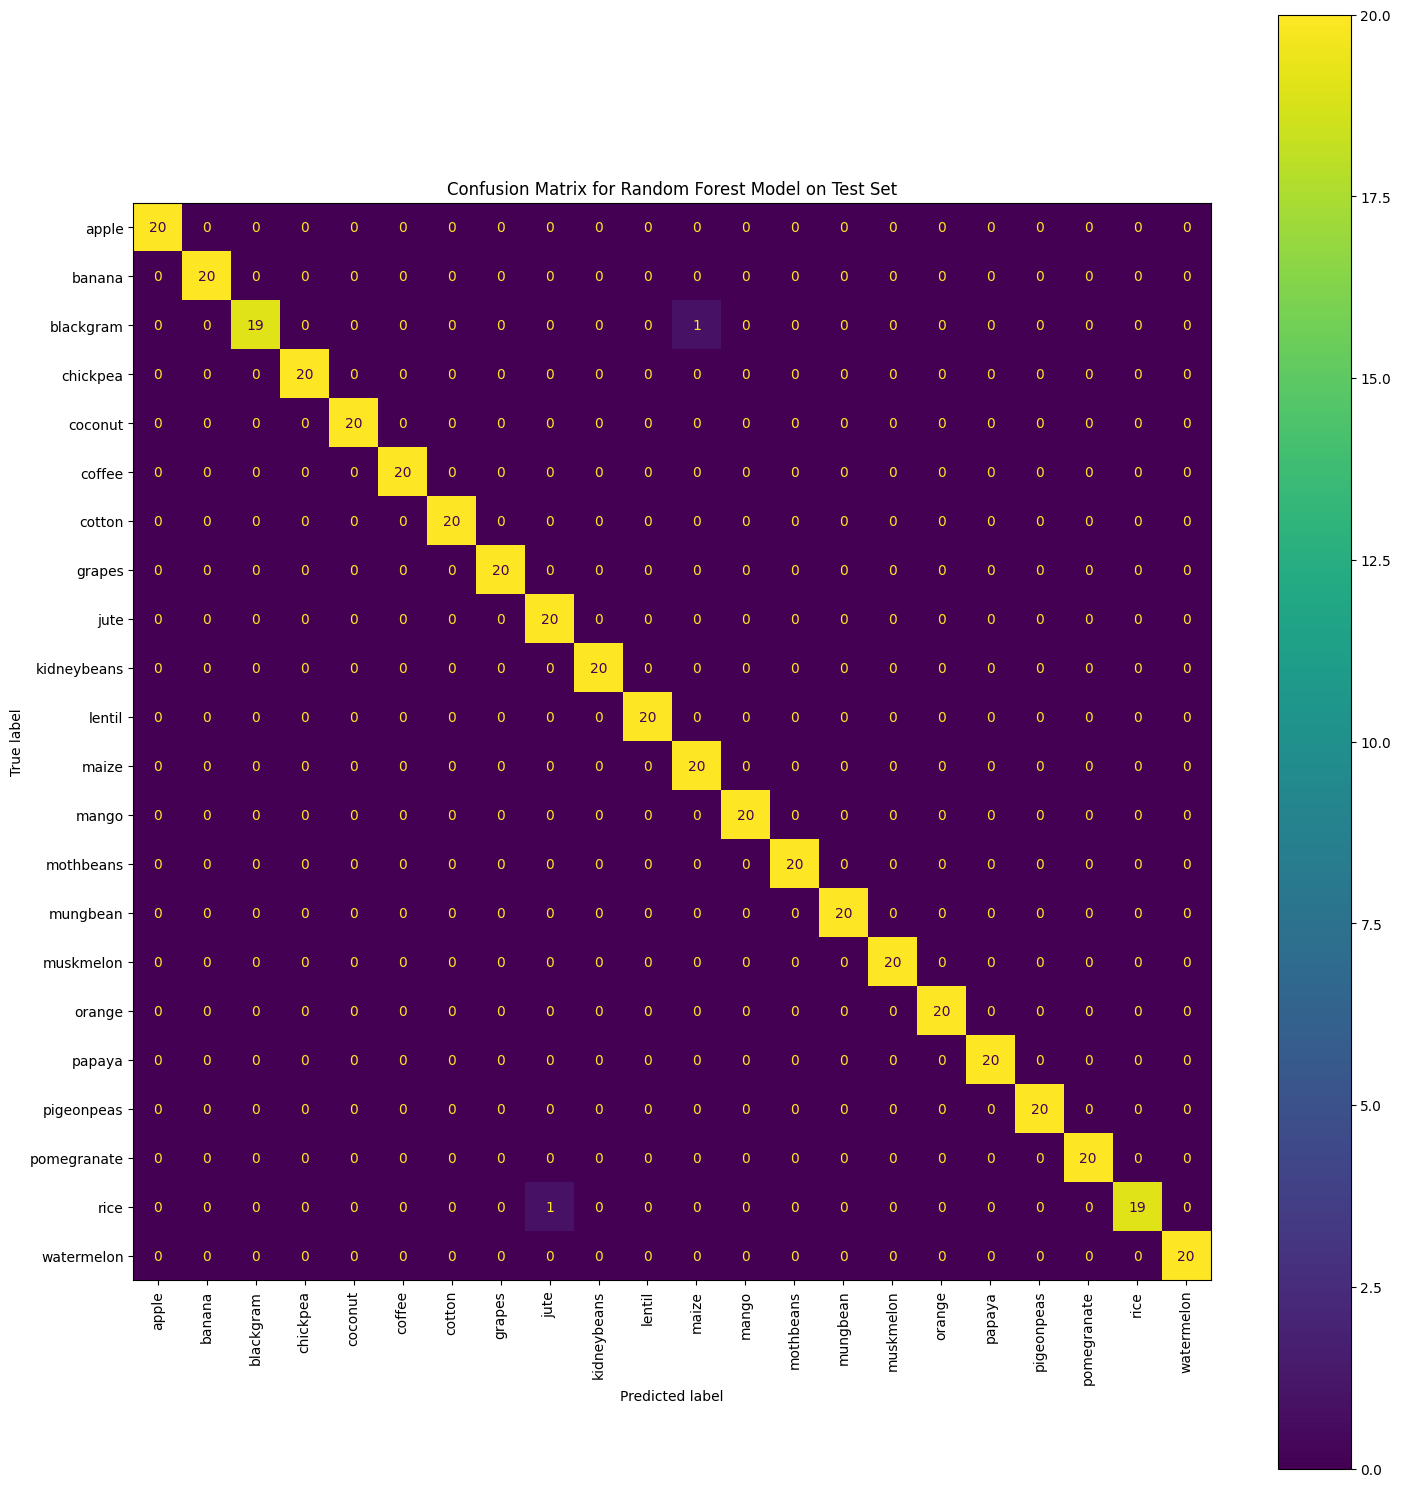

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=class_labels)

fig, ax = plt.subplots(figsize=(15, 15))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
display_cm.plot(cmap='viridis', ax=ax, xticks_rotation='vertical')
ax.set_title('Confusion Matrix for Random Forest Model on Test Set')
plt.tight_layout()
plt.show()

## Feature Importance Analysis (Optional)

We have to Conduct a permutation feature importance analysis to identify which soil and climate variables contribute most significantly to the model's predictions. This will provide deeper insights into the dataset.



I will import the necessary function, perform the permutation importance calculation, and then process and print the results.





In [ ]:
# Prompt - port the necessary function, perform the permutation importance calculation, and then process and print the results.

from sklearn.inspection import permutation_importance
import pandas as pd

# 1. & 2. Perform permutation feature importance
result = permutation_importance(best_rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# 3. Store the results in a variable (already done with 'result')

# 4. Create a pandas Series of feature importances
feature_importances = pd.Series(result.importances_mean, index=X_test.columns)

# 5. Sort the feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# 6. Print the sorted feature importances
print("Permutation Feature Importances (Random Forest Model):")
print(sorted_importances)

Permutation Feature Importances (Random Forest Model):
humidity       0.332273
N              0.260682
rainfall       0.174545
K              0.152500
P              0.115000
temperature    0.008864
ph             0.007273
dtype: float64


I will visualize the sorted feature importances using a bar plot to provide a clear understanding of the most influential features.





/tmp/ipykernel_4462/1661296801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


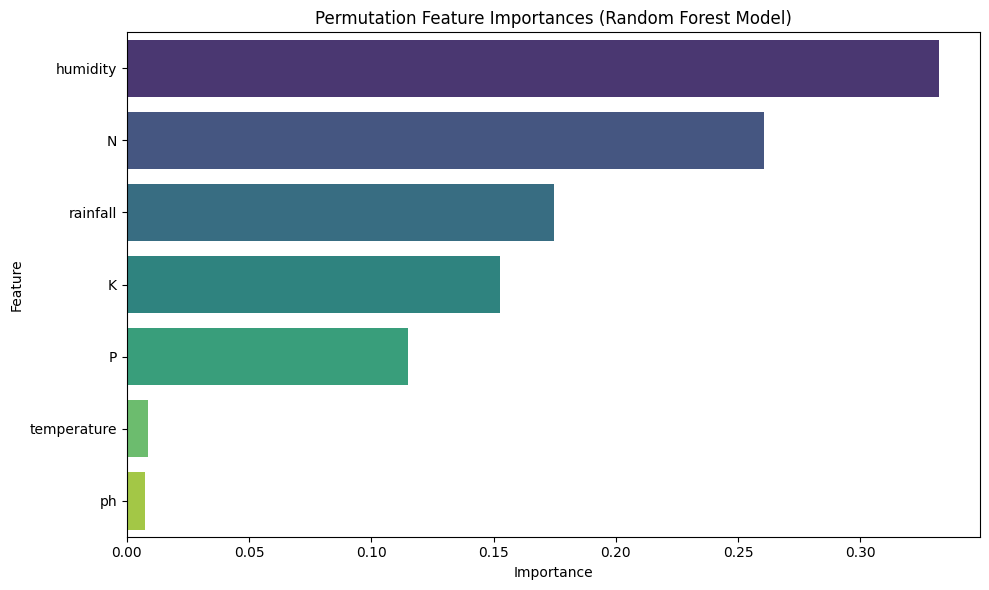

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Visualize the feature importances using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Permutation Feature Importances (Random Forest Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Deployment

Saving the Model for the future for predictions in real-time.


In [ ]:
import pickle

# Define the filename for the saved model
model_filename = 'random_forest_model.pkl'

# Save the best-performing model (Random Forest) to a file
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)

print(f"Best performing Random Forest model saved as '{model_filename}'")

Best performing Random Forest model saved as 'random_forest_model.pkl'


In [ ]:
import pickle

# Define the filename for the saved scaler
scaler_filename = 'standard_scaler.pkl'

# Save the StandardScaler to a file
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"StandardScaler saved as '{scaler_filename}'")

StandardScaler saved as 'standard_scaler.pkl'


We'll create a Gradio interface to interact with the saved model and make predictions.

 It's an interactive web-based interface has been developed using Gradio. This interface allows users to input soil and environmental parameters directly and receive immediate crop recommendations. This serves as a user-friendly demonstration of the model's capabilities and can be easily shared for preliminary testing and stakeholder feedback.

In [ ]:
# Install Gradio if not already installed
!pip install -q gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import pickle

# Load the trained model
model_filename = 'random_forest_model.pkl'
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Load the scaler
scaler_filename = 'standard_scaler.pkl'
with open(scaler_filename, 'rb') as file:
    loaded_scaler = pickle.load(file)

# Define the prediction function
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                              columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])

    # Scale the input data using the loaded scaler
    scaled_input = loaded_scaler.transform(input_data)

    # Make prediction
    prediction = loaded_model.predict(scaled_input)[0]

    return f"The recommended crop is: {prediction}"

# Create Gradio interface
iface = gr.Interface(
    fn=predict_crop,
    inputs=[
        gr.Number(label="Nitrogen (N) (0-140)", minimum=0, maximum=140, value=50),
        gr.Number(label="Phosphorus (P) (5-145)", minimum=5, maximum=145, value=50),
        gr.Number(label="Potassium (K) (5-205)", minimum=5, maximum=205, value=50),
        gr.Number(label="Temperature (°C) (8.8-43.7)", minimum=8.8, maximum=43.7, value=25),
        gr.Number(label="Humidity (%) (14.2-100)", minimum=14.2, maximum=100, value=70),
        gr.Number(label="pH (3.5-9.9)", minimum=3.5, maximum=9.9, value=6.5),
        gr.Number(label="Rainfall (mm) (20.2-298.6)", minimum=20.2, maximum=298.6, value=100)
    ],
    outputs="text",
    title="Crop Recommendation System",
    description="Enter the soil and environmental parameters to get a crop recommendation."
)

# Launch the interface
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4379eef5e6bef625a7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Click on the link above the interface to test it out